# Decomposing Stock Prices into Trend, Cyclic, Seasonal & Residual Components

This notebook decomposes three real stock price series — **NVIDIA (NVDA)**,
**Microsoft (MSFT)** and **Apple (AAPL)** — into four interpretable pieces:

$$ \text{Price}_t = \text{Trend}_t + \text{Cyclic}_t + \text{Seasonal}_t + \text{Residual}_t $$

| Component | What it means | Time horizon |
|---|---|---|
| **Trend** | The smooth, long-run direction of the price | Multi-year |
| **Cyclic** | Swings around the trend with *no fixed period* — "bull" and "bear" phases | Months to a few years |
| **Seasonal** | A *fixed, repeating* calendar pattern (e.g. a January effect) | Exactly 1 year (period=12) |
| **Residual** | Whatever is left — news shocks, earnings surprises, noise | Days to weeks |

We build this up in stages so each idea is visible on its own before we combine them.


## Why one decomposition tool isn't enough

The classic tool for this job is **STL** (*Seasonal-Trend decomposition using LOESS*).
STL is excellent, but it only splits a series into:

$$ \text{Price}_t = \underbrace{\text{Trend-Cycle}_t}_{\text{smooth, long-run}} + \text{Seasonal}_t + \text{Residual}_t $$

Notice: **trend and cycle come out as one merged component.** STL alone cannot tell you
"this part is the 10-year uptrend" vs "this part is the 18-month bull run inside it."

To split trend from cycle, we add a second stage: the **Hodrick-Prescott (HP) filter**,
a standard econometric tool (originally built for GDP data) that takes any smooth
series and separates it into:

$$ \text{Trend-Cycle}_t = \text{Trend}_t + \text{Cyclic}_t $$

**Our pipeline, in short:**

1. Resample daily prices → monthly average (gives a clean, evenly-spaced series)
2. Log-transform the price (stabilizes variance — stock prices grow multiplicatively)
3. **STL** → separates out the **Seasonal** component and a **Trend-Cycle** blob
4. **HP filter** on that Trend-Cycle blob → separates **Trend** from **Cyclic**
5. Whatever STL called "Residual" stays as our final **Residual**

Let's do it.


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from decomposition import (
    load_stock_csv, to_monthly, log_transform,
    stl_decompose, hp_split_trend_cycle, full_decomposition
)

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


## Step 0 — Load the three datasets

Each CSV has a different column layout, so `load_stock_csv` just needs to know the date column and close-price column name for each file.

In [2]:
nvda_daily = load_stock_csv('../data/nvidia_stock_2015_to_2024.csv', 'date', 'close')
msft_daily = load_stock_csv('../data/msft_stock_1986_2026.csv', 'Date', 'Close')
aapl_daily = load_stock_csv('../data/aapl_stock_1984_2025.csv', 'Date', 'Close')

for name, s in [('NVDA', nvda_daily), ('MSFT', msft_daily), ('AAPL', aapl_daily)]:
    print(f"{name}: {len(s):>6} daily rows | {s.index.min().date()} -> {s.index.max().date()}")


NVDA:   2369 daily rows | 2015-01-02 -> 2024-05-31
MSFT:  10072 daily rows | 1986-03-13 -> 2026-03-05
AAPL:  10171 daily rows | 1984-09-07 -> 2025-01-17


## Step 1 — Resample to monthly & take logs

**Why monthly, not daily?**
Markets are closed on weekends, so a naive "period = 7 days" seasonal search on daily
data is meaningless — you'd just be rediscovering the weekend gap. Monthly averaging
gives us evenly spaced points where a `period = 12` (yearly) seasonal search is a
meaningful, testable hypothesis (e.g. "Do stocks reliably do something every December?").

**Why logs?**
A stock going from \$10 to \$20 and one going from \$500 to \$510 both moved \$10 — but
the first is a 100% move and the second is a 2% move. Prices grow *multiplicatively*,
and their volatility scales with their level. Taking logs turns multiplicative growth
into additive growth, which is the assumption the decomposition math relies on. We
`np.exp()` everything back to dollars at the end.


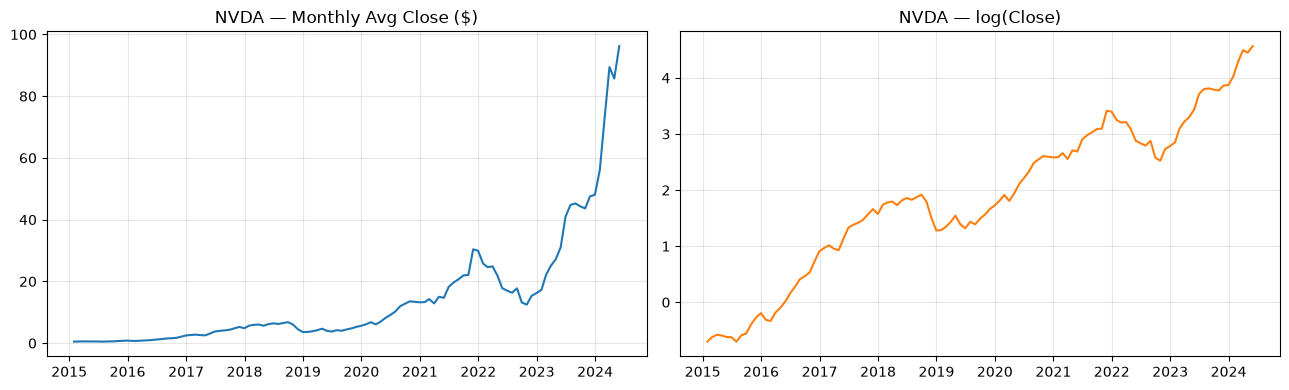

In [3]:
nvda_m = to_monthly(nvda_daily)
msft_m = to_monthly(msft_daily)
aapl_m = to_monthly(aapl_daily)

nvda_log = log_transform(nvda_m)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(nvda_m.index, nvda_m.values, color='tab:blue')
axes[0].set_title('NVDA — Monthly Avg Close ($)')
axes[1].plot(nvda_log.index, nvda_log.values, color='tab:orange')
axes[1].set_title('NVDA — log(Close)')
plt.tight_layout()
plt.savefig('../outputs/01_raw_vs_log_nvda.png', dpi=110)
plt.show()


## Step 2 — STL decomposition (Stage 1)

`STL` needs a `period`: the number of observations in one full seasonal cycle.
On monthly data, `period=12` searches for a pattern that repeats every 12 months.

`robust=True` down-weights extreme outlier months (e.g. the COVID crash, a huge
earnings-driven spike) so a handful of extreme events don't distort the whole
trend-cycle line.

STL returns three pieces. Note the middle one is **trend + cycle merged together** —
splitting that further is Step 3.


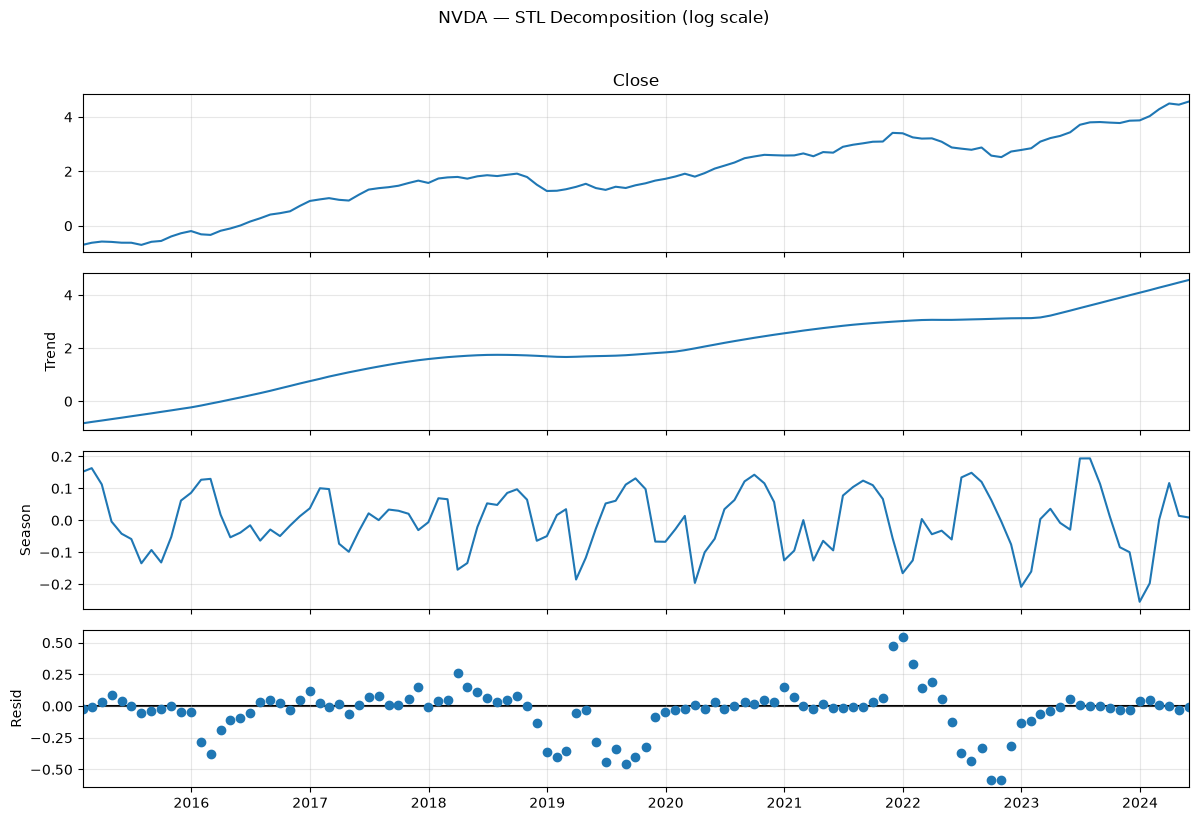

In [4]:
stl_result = stl_decompose(nvda_log, period=12, robust=True)

fig = stl_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle('NVDA — STL Decomposition (log scale)', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_stl_nvda.png', dpi=110, bbox_inches='tight')
plt.show()


## Step 3 — HP filter: splitting Trend-Cycle into Trend + Cyclic (Stage 2)

The Hodrick-Prescott filter solves an optimization problem: find the smoothest
possible trend line such that the leftover "cycle" doesn't wiggle too wildly. A
parameter **λ (lambda)** controls that smoothness trade-off:

- Larger λ → smoother trend, more variation pushed into the cyclic component
- Smaller λ → trend hugs the data more closely, less left for cyclic

Standard conventions (Ravn & Uhlig, 2002):

| Data frequency | Recommended λ |
|---|---|
| Annual | 6.25 |
| Quarterly | 1600 |
| **Monthly (ours)** | **129,600** |

Try changing `lamb` below and re-running to see how the trend/cyclic split changes.


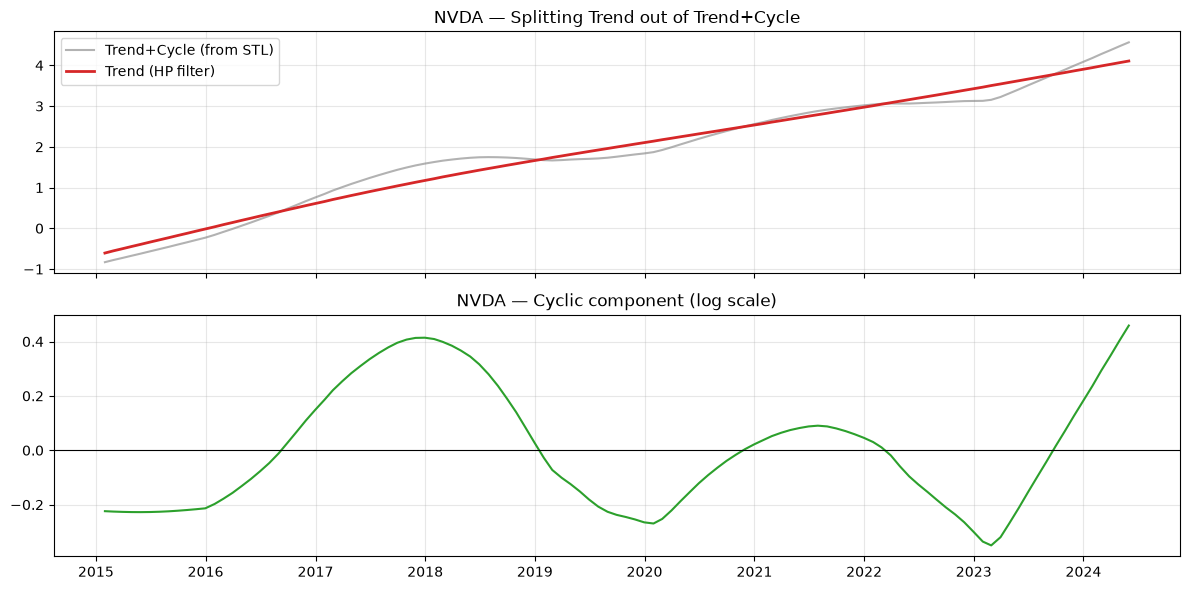

In [5]:
trend_cycle_log = stl_result.trend
seasonal_log = stl_result.seasonal
resid_log = stl_result.resid

trend_log, cyclic_log = hp_split_trend_cycle(trend_cycle_log, lamb=129600)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(trend_cycle_log.index, trend_cycle_log.values, label='Trend+Cycle (from STL)', color='gray', alpha=0.6)
axes[0].plot(trend_log.index, trend_log.values, label='Trend (HP filter)', color='tab:red', linewidth=2)
axes[0].legend(); axes[0].set_title('NVDA — Splitting Trend out of Trend+Cycle')

axes[1].plot(cyclic_log.index, cyclic_log.values, color='tab:green')
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('NVDA — Cyclic component (log scale)')
plt.tight_layout()
plt.savefig('../outputs/03_hp_split_nvda.png', dpi=110)
plt.show()


## Step 4 — Put it all together, back in dollar terms

`full_decomposition()` in `src/decomposition.py` runs all the steps above end-to-end
and converts everything back from log-space to dollars. It also produces a
**`reconstructed`** column — adding trend + cyclic + seasonal + resid back together
should closely match the original close price. That reconstruction check is your
sanity check that nothing was lost along the way.


In [6]:
nvda_decomp = full_decomposition(nvda_m, period=12, lamb=129600)
nvda_decomp.tail()


,close,trend,cyclic,seasonal,resid,reconstructed
Date,,,,,,
2024-01-31,56.259190,51.604778,13.788546,-11.694189,2.560055,56.259190
2024-02-29,72.550451,53.737893,18.245675,0.129339,0.437544,72.550451
2024-03-31,89.442550,55.960273,23.278447,9.813550,0.390280,89.442550
2024-04-30,85.703909,58.275157,28.948257,1.237659,-2.757163,85.703909
2024-05-31,96.220182,60.686013,35.322434,0.867569,-0.655834,96.220182


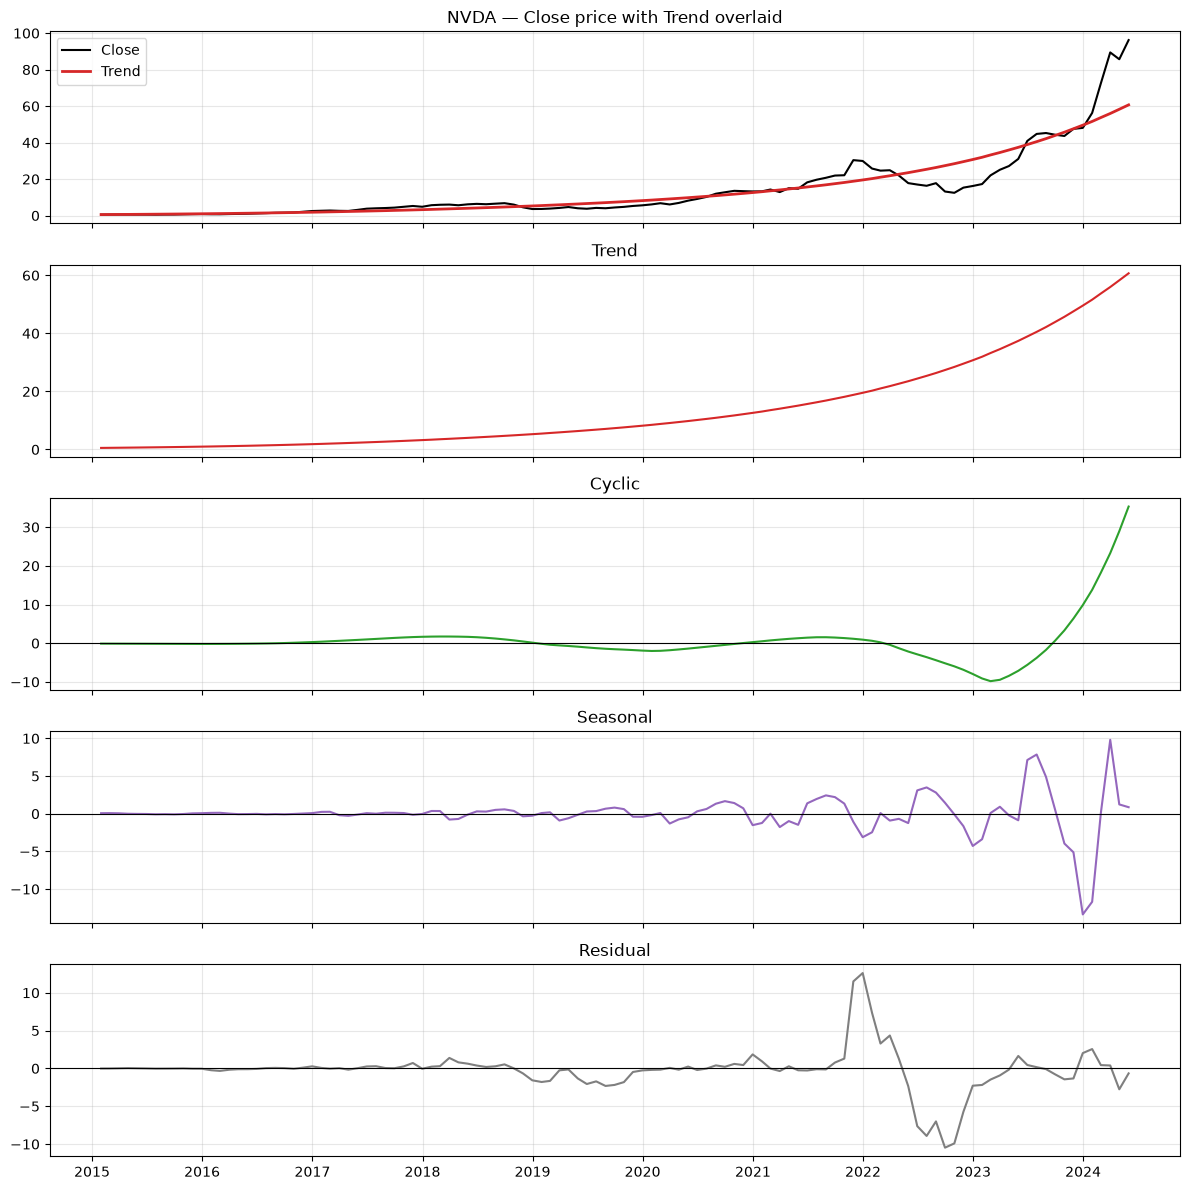

In [7]:
def plot_decomposition(decomp: pd.DataFrame, ticker: str, save_path: str = None):
    fig, axes = plt.subplots(5, 1, figsize=(12, 12), sharex=True)

    axes[0].plot(decomp.index, decomp['close'], color='black', label='Close')
    axes[0].plot(decomp.index, decomp['trend'], color='tab:red', label='Trend', linewidth=2)
    axes[0].legend(loc='upper left'); axes[0].set_title(f'{ticker} — Close price with Trend overlaid')

    axes[1].plot(decomp.index, decomp['trend'], color='tab:red')
    axes[1].set_title('Trend')

    axes[2].plot(decomp.index, decomp['cyclic'], color='tab:green')
    axes[2].axhline(0, color='black', linewidth=0.8)
    axes[2].set_title('Cyclic')

    axes[3].plot(decomp.index, decomp['seasonal'], color='tab:purple')
    axes[3].axhline(0, color='black', linewidth=0.8)
    axes[3].set_title('Seasonal')

    axes[4].plot(decomp.index, decomp['resid'], color='tab:gray')
    axes[4].axhline(0, color='black', linewidth=0.8)
    axes[4].set_title('Residual')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=110, bbox_inches='tight')
    plt.show()

plot_decomposition(nvda_decomp, 'NVDA', save_path='../outputs/04_full_decomposition_nvda.png')


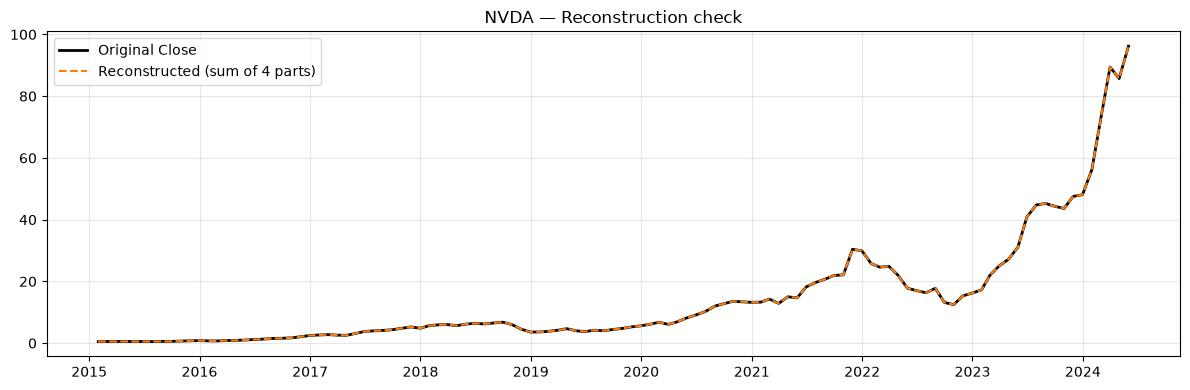

Max reconstruction error: 0.0000% of price -- should be tiny (floating point only)


In [8]:
# Reconstruction sanity check: close vs (trend + cyclic + seasonal + resid)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(nvda_decomp.index, nvda_decomp['close'], label='Original Close', color='black', linewidth=2)
ax.plot(nvda_decomp.index, nvda_decomp['reconstructed'], label='Reconstructed (sum of 4 parts)',
        color='tab:orange', linestyle='--')
ax.legend(); ax.set_title('NVDA — Reconstruction check')
plt.tight_layout()
plt.savefig('../outputs/05_reconstruction_check_nvda.png', dpi=110)
plt.show()

max_error_pct = ((nvda_decomp['close'] - nvda_decomp['reconstructed']).abs() / nvda_decomp['close']).max() * 100
print(f"Max reconstruction error: {max_error_pct:.4f}% of price -- should be tiny (floating point only)")


## Step 5 — Run the same pipeline on MSFT and AAPL

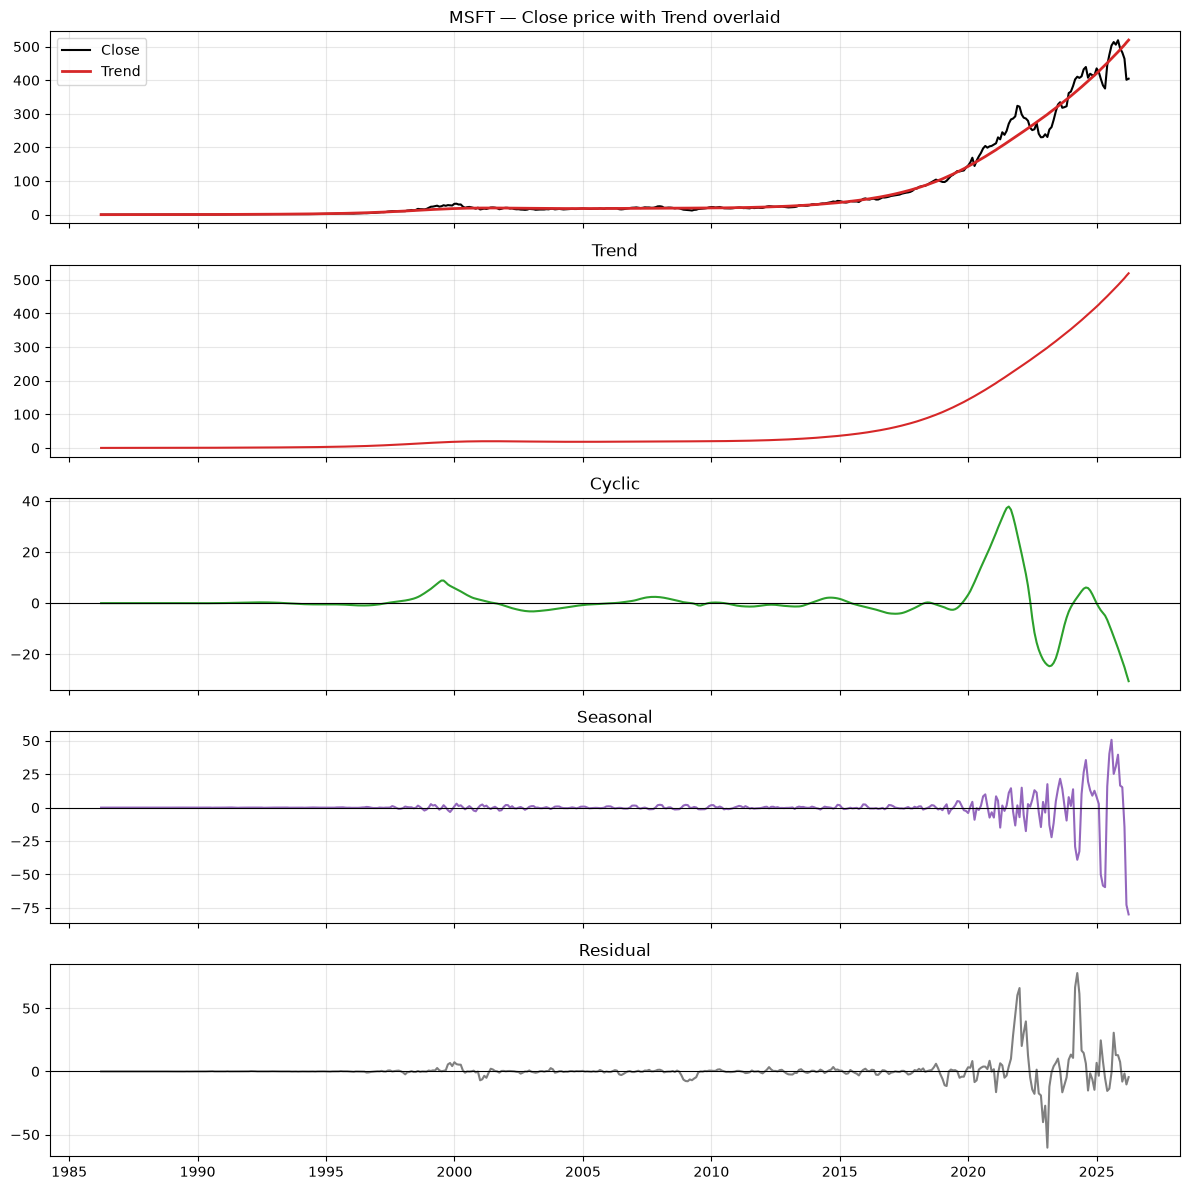

In [9]:
msft_decomp = full_decomposition(msft_m, period=12, lamb=129600)
aapl_decomp = full_decomposition(aapl_m, period=12, lamb=129600)

plot_decomposition(msft_decomp, 'MSFT', save_path='../outputs/06_full_decomposition_msft.png')


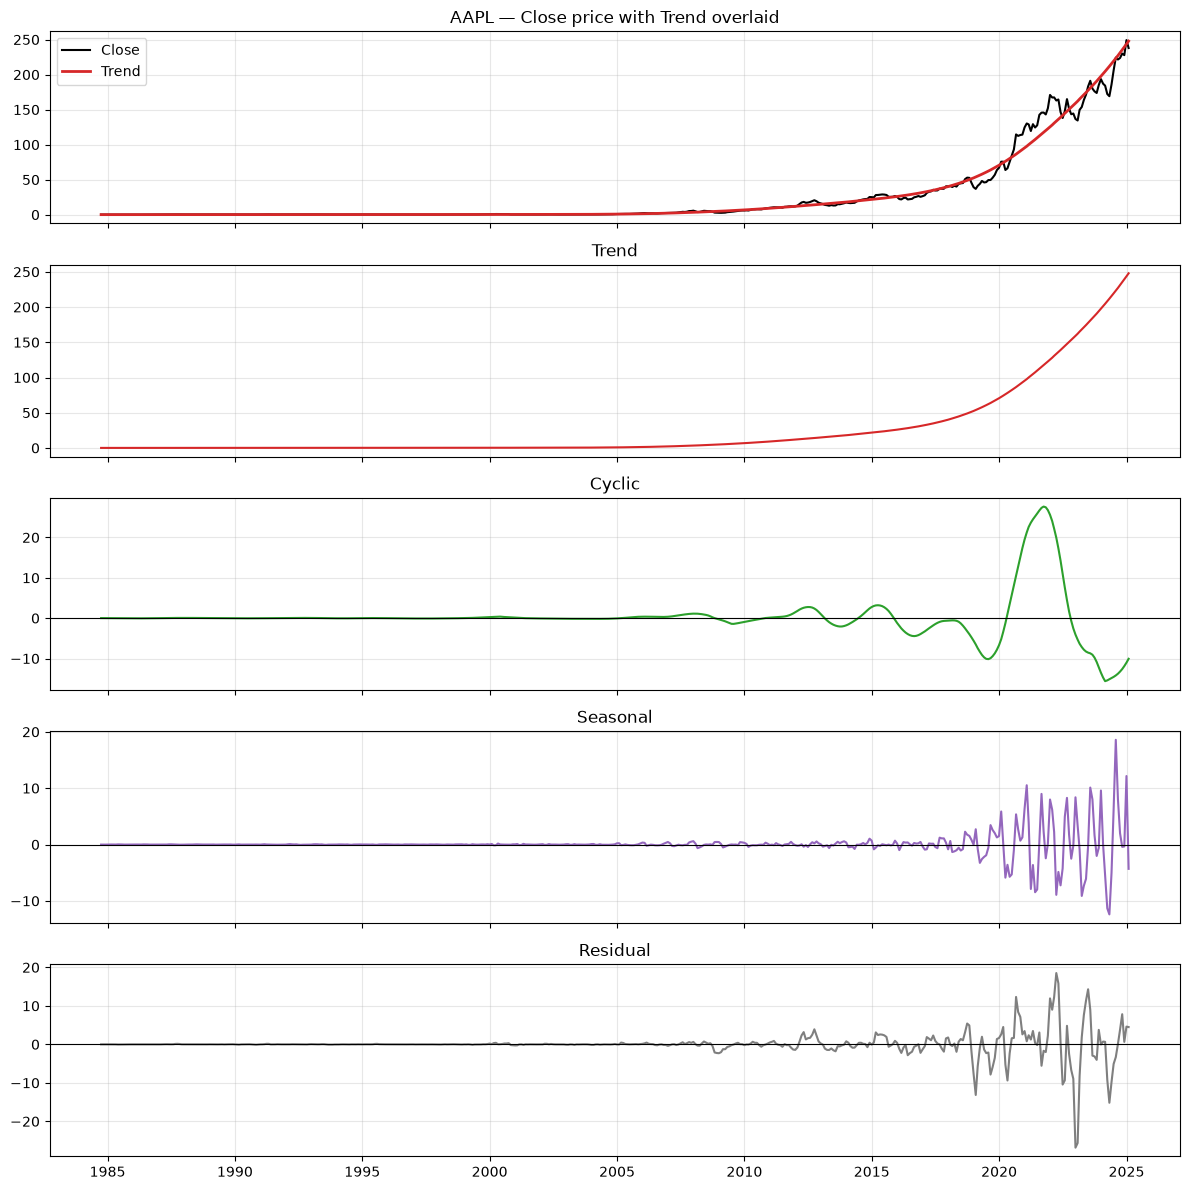

In [10]:
plot_decomposition(aapl_decomp, 'AAPL', save_path='../outputs/07_full_decomposition_aapl.png')


## Step 6 — Save results to CSV (for use outside this notebook)

In [11]:
nvda_decomp.to_csv('../outputs/nvda_decomposition.csv')
msft_decomp.to_csv('../outputs/msft_decomposition.csv')
aapl_decomp.to_csv('../outputs/aapl_decomposition.csv')
print("Saved decomposition results to outputs/")


Saved decomposition results to outputs/


## How to read your results

- **Trend**: the long-run growth line. Compare slopes across companies — this is
  where you'd point to say "NVDA's trend accelerated sharply from 2023 onward" (the
  AI/GPU demand story).
- **Cyclic**: multi-month swings around the trend. Sustained positive stretches
  look like bull-market phases inside the stock; sustained negative stretches
  look like drawdowns/corrections — even while the long-run trend stays up.
- **Seasonal**: a small, repeating wiggle by calendar month. **Be skeptical of
  this one** — under the Efficient Market Hypothesis, reliable, exploitable
  calendar patterns in stock prices shouldn't persist (if they did, traders would
  arbitrage them away). Expect this component to be small relative to trend and
  cyclic; if it looks unrealistically large, that's a sign of overfitting rather
  than a real effect.
- **Residual**: everything the model couldn't explain — earnings surprises,
  news shocks, one-off events. Large spikes here often line up with real-world
  events you can look up (e.g. a specific earnings call or macro shock).

### Things worth trying next
- Change `lamb` (HP filter smoothness) and watch trend vs cyclic trade off
- Change `period` to `5` on **daily** (not monthly) data to check for a
  day-of-week effect instead of a month-of-year effect
- Swap the HP filter for the **Christiano-Fitzgerald bandpass filter**
  (`statsmodels.tsa.filters.cf_filter`), which isolates cycles within a
  chosen wavelength range instead of just "whatever's left after trend"
- Compare the cyclic component's turning points across NVDA/MSFT/AAPL —
  do their "bull/bear" phases move together, or independently?
